# 05 â€” Forward cash-out forecast

*"Predictive Analytics Framework to Forecast Likely Cash Withdrawal Locations
**in Advance**"* â€” SIH26184, MHA / I4C.

Those last two words are the whole notebook. I4C already runs **Pratibimb**,
which maps cybercrime geographically, and **Samanvaya**, which coordinates the
case data. A heatmap of where cash-outs *have* happened is not a contribution to
people who built one; it is a re-implementation of their own tool.

So the question this engine answers is deliberately a different one:

> Given the complaints that are open **right now**, where will the money surface
> in the next 30 / 60 / 120 minutes?

That is a forecast conditioned on live evidence, and history enters only as a
capped tie-breaker. This notebook takes the claim apart and checks each piece
against `data/metrics.json`.

**Nothing here is retrained.** The surface is arithmetic over the shipped
checkpoint's own outputs â€” the conditional-logit ATM posterior and the q05 /
median / q95 countdown band â€” which is why adding it cost no model risk.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# Works whether the kernel starts in notebooks/ or at the project root.
ROOT = Path.cwd()
while not (ROOT / "engine").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "engine"))

DATA = ROOT / "data"
MODELS = ROOT / "models"

# The published numbers. Everything below is checked against this file.
METRICS = json.loads((DATA / "metrics.json").read_text())

def check(label, got, expected, tol=5e-3):
    """Print whether a freshly computed figure matches the published one."""
    ok = abs(float(got) - float(expected)) <= tol
    print(f"  {'MATCH   ' if ok else 'MISMATCH'}  {label:38s} "
          f"notebook={float(got):.4f}  published={float(expected):.4f}")
    return ok

print("project root :", ROOT)
print("metrics from :", METRICS["_about"][:60], "...")

project root : D:\SIH 2026\SIHPROJECT2
metrics from : Measured figures for MuleShield AI (SIH26184). Written by th ...


## 1 Â· The formula, and the one constant that carries the argument

For each open complaint *i*, the shipped ranker gives a calibrated posterior over
25 candidate ATMs, and the shipped regressor gives a countdown band. Project the
first onto geographic cells and the second onto time windows:

$$\text{cond}[c][w] \;=\; \sum_i P(c \mid i)\; P(w \mid i)\; \text{amount}_i$$

Then history is added as **one capped term**:

$$\text{score}[c][w] \;=\; \text{cond}[c][w] \;+\; \lambda \cdot \text{prior\_share}[c] \cdot \textstyle\sum_c \text{cond}[c][w], \qquad \lambda = 0.15$$

The prior can reorder cells. It can never carry more than ~15% of the surface's
mass. That single constant is what separates this from a density map, so it is a
module constant, it is returned in the API response, and a test fails if the
measured national share exceeds it.

In [2]:
import hotspot as H

hs = METRICS["hotspot"]

print("PRIOR_WEIGHT      :", H.PRIOR_WEIGHT)
print("CELL_RADIUS_KM    :", H.CELL_RADIUS_KM)
print("WINDOWS (minutes) :", H.WINDOWS)
print()
print("published surface decomposition, measured on a real surface:")
print(f"  prior_share_national = {hs['prior_share_national']}  "
      f"(cap {hs['prior_weight']})")
assert hs["prior_share_national"] <= hs["prior_weight"] + 1e-9, \
    "the prior is over its cap -- this would be a density map wearing a forecast's name"
print("  within cap: OK")

PRIOR_WEIGHT      : 0.15
CELL_RADIUS_KM    : 12.0
WINDOWS (minutes) : ((0, 30), (30, 60), (60, 120))

published surface decomposition, measured on a real surface:
  prior_share_national = 0.1304  (cap 0.15)
  within cap: OK


## 2 Â· Cells: why 12 km, and why not districts

A district is a political unit, not a deployable one. 1,000 ATMs across 78
districts is ~13 machines each, and a district can be 200 km wide. A 12 km cell
is roughly a patrol's one-hour reach, which is the unit an officer can actually
be sent to. District and state ride along on every cell as roll-up keys, so
drill-down is a `group by` rather than a second model.

Greedy-leader clustering, rebuilt here from the real ATM directory.

cells               : 222   (published 222)
ATMs per cell       : median 4, mean 4.5, max 15
total ATMs covered  : 1000  (directory has 1000)


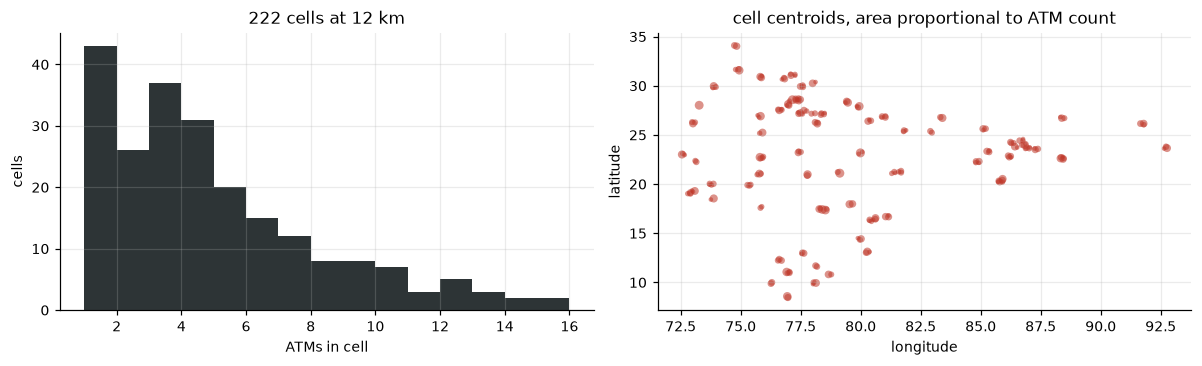

In [3]:
atm = pd.read_csv(DATA / "atm_directory.csv")
# build_cells takes row mappings, the way state.py hands it
# atm_directory.values(). Iterating a DataFrame yields column NAMES.
cells = H.build_cells(atm.to_dict("records"))
sizes = np.array([m["atm_count"] for m in cells.values()])

print(f"cells               : {len(cells)}   (published {hs['n_cells']})")
print(f"ATMs per cell       : median {np.median(sizes):.0f}, "
      f"mean {sizes.mean():.1f}, max {sizes.max()}")
print(f"total ATMs covered  : {sizes.sum()}  (directory has {len(atm)})")
assert sizes.sum() == len(atm), "a machine fell out of the cell partition"

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(sizes, bins=range(1, sizes.max() + 2), color="#2d3436")
ax[0].set_xlabel("ATMs in cell"); ax[0].set_ylabel("cells")
ax[0].set_title(f"{len(cells)} cells at {H.CELL_RADIUS_KM:.0f} km")

lats = [m["lat"] for m in cells.values()]
lons = [m["lon"] for m in cells.values()]
ax[1].scatter(lons, lats, s=np.sqrt(sizes) * 9, c="#c0392b", alpha=0.55,
              edgecolors="none")
ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude")
ax[1].set_title("cell centroids, area proportional to ATM count")
plt.tight_layout(); plt.show()

## 3 Â· The temporal kernel is derived, not invented

A complaint's countdown arrives as three numbers â€” q05, median, q95. Fitting a
lognormal through them gives a full distribution, and the mass in a window is
then a plain integral.

The part that matters operationally is the **conditional survival**
renormalisation. The withdrawal has not happened yet, so we condition on
$T > e$ where $e$ is minutes elapsed since filing:

$$P(w \mid i) \;=\; \frac{\Phi\!\left(\frac{\ln(e + w_1) - \mu}{\sigma}\right) - \Phi\!\left(\frac{\ln(e + w_0) - \mu}{\sigma}\right)}{1 - \Phi\!\left(\frac{\ln e - \mu}{\sigma}\right)}$$

That is what makes stale complaints fall out of the surface on their own instead
of by a hand-tuned decay: as $e$ grows past the median, the numerator shrinks
faster than the denominator and the complaint stops contributing.

,0-30,30-60,60-120,total
elapsed_min,,,,
0,0.2963,0.4184,0.2378,0.9525
15,0.5193,0.2929,0.1544,0.9666
30,0.5945,0.2452,0.1298,0.9695
45,0.6093,0.2317,0.1266,0.9676
60,0.6047,0.2287,0.1304,0.9638
90,0.5786,0.2310,0.1439,0.9535


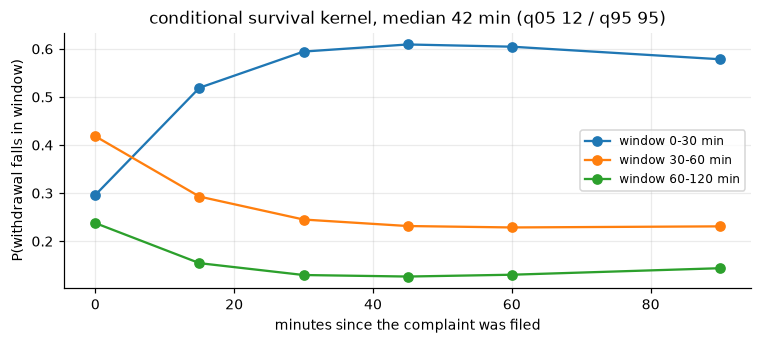

A complaint 90 minutes old still carries 95.3% of its mass in the next 2 hours; a fresh one carries 95.2%.


In [4]:
median, lo, hi = 42.0, 12.0, 95.0
elapsed_grid = [0, 15, 30, 45, 60, 90]

rows = []
for e in elapsed_grid:
    r = {"elapsed_min": e}
    for w in H.WINDOWS:
        r[f"{w[0]}-{w[1]}"] = round(H.window_mass(median, lo, hi, e, w[0], w[1]), 4)
    r["total"] = round(sum(H.window_mass(median, lo, hi, e, w[0], w[1])
                           for w in H.WINDOWS), 4)
    rows.append(r)
kernel = pd.DataFrame(rows).set_index("elapsed_min")
display(kernel)

fig, ax = plt.subplots(figsize=(7, 3.2))
for w in H.WINDOWS:
    ax.plot(elapsed_grid,
            [H.window_mass(median, lo, hi, e, w[0], w[1]) for e in elapsed_grid],
            marker="o", label=f"window {w[0]}-{w[1]} min")
ax.set_xlabel("minutes since the complaint was filed")
ax.set_ylabel("P(withdrawal falls in window)")
ax.set_title(f"conditional survival kernel, median {median:.0f} min "
             f"(q05 {lo:.0f} / q95 {hi:.0f})")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("A complaint 90 minutes old still carries "
      f"{kernel.loc[90, 'total']:.1%} of its mass in the next 2 hours; "
      f"a fresh one carries {kernel.loc[0, 'total']:.1%}.")

## 4 Â· The result: hit rate, PAI, and rupees covered

Not accuracy. Accuracy over 222 cells is meaningless â€” always predicting "not
here" scores 99.5%.

**PAI** (Predictive Accuracy Index) is the crime-forecasting standard: the share
of events captured divided by the share of area flagged. PAI = 1 is what you get
by flagging area at random, so it reads directly as *how many times better than
chance*. Area is proxied by ATM share, stated explicitly, because a team is
dispatched to machines rather than to square kilometres.

**PEI** degenerates to the hit rate here and the ledger says so: with exactly one
true cell per event, the oracle at coverage *k* captures everything, so
PEI = PAI / PAI_oracle = hit rate. Publishing it without that note would be
publishing a number that looks like a second measurement and is not one.

,hit_rate,PAI,rupees_cover,ATM_share,area_km2
k cells,,,,,
1,0.5153,70.469,0.5327,0.0073,452.4
2,0.7391,57.154,0.7664,0.0129,904.8
3,0.8696,45.883,0.8916,0.0190,1357.2
5,0.9517,26.862,0.9561,0.0354,2261.9
10,0.9936,12.935,0.9958,0.0768,4523.9
20,1.0000,6.357,1.0000,0.1573,9047.8


operating point k=5:
  95.17% of held-out cash-outs land in a flagged cell
  95.61% of the rupees at risk are covered
  while flagging 3.54% of the ATM estate
  PAI 26.86 -- that many times better than flagging at random

  n = 621 held-out cash-outs, 250 held-out complaints


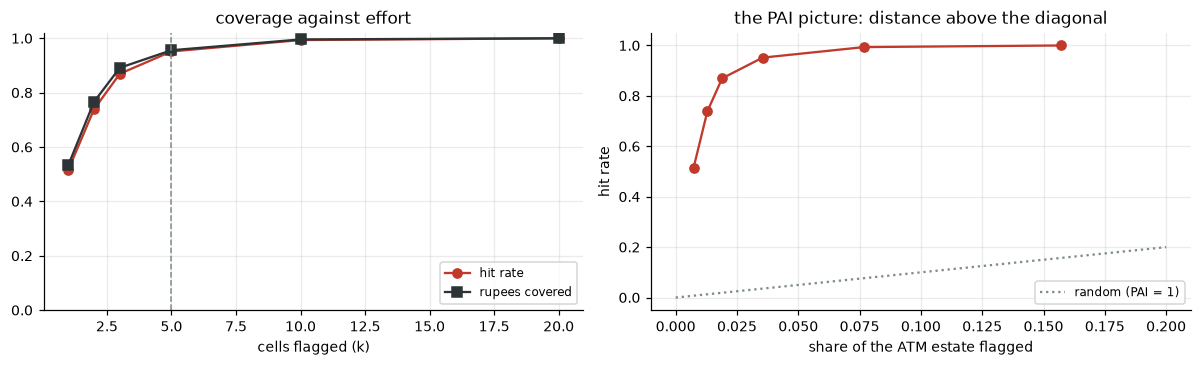

In [5]:
K = [1, 2, 3, 5, 10, 20]
tab = pd.DataFrame({
    "hit_rate":     [hs["hit_rate_at_k"][str(k)] for k in K],
    "PAI":          [hs["pai_at_k"][str(k)] for k in K],
    "rupees_cover": [hs["rupees_covered_at_k"][str(k)] for k in K],
    "ATM_share":    [hs["flagged_atm_share_at_k"][str(k)] for k in K],
    "area_km2":     [hs["flagged_area_km2_at_k"][str(k)] for k in K],
}, index=pd.Index(K, name="k cells"))
display(tab.round(4))

k5 = str(hs["operating_k_cells"])
print(f"operating point k={k5}:")
print(f"  {hs['hit_rate_at_k'][k5]:.2%} of held-out cash-outs land in a flagged cell")
print(f"  {hs['rupees_covered_at_k'][k5]:.2%} of the rupees at risk are covered")
print(f"  while flagging {hs['flagged_atm_share_at_k'][k5]:.2%} of the ATM estate")
print(f"  PAI {hs['pai_at_k'][k5]:.2f} -- that many times better than flagging at random")
print(f"\n  n = {hs['n_test_cashouts']} held-out cash-outs, "
      f"{hs['n_test_complaints']} held-out complaints")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(K, tab["hit_rate"], marker="o", color="#c0392b", label="hit rate")
ax[0].plot(K, tab["rupees_cover"], marker="s", color="#2d3436", label="rupees covered")
ax[0].axvline(int(k5), ls="--", c="#7f8c8d", lw=1)
ax[0].set_xlabel("cells flagged (k)"); ax[0].set_ylim(0, 1.02)
ax[0].set_title("coverage against effort"); ax[0].legend(fontsize=8)

ax[1].plot(tab["ATM_share"], tab["hit_rate"], marker="o", color="#c0392b")
ax[1].plot([0, 0.2], [0, 0.2], ls=":", c="#7f8c8d", label="random (PAI = 1)")
ax[1].set_xlabel("share of the ATM estate flagged"); ax[1].set_ylabel("hit rate")
ax[1].set_title("the PAI picture: distance above the diagonal")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5 Â· The baseline that matters, and the one that beats us

Four baselines, and the ordering is the argument.

`baseline_historical_density` **is Pratibimb** â€” cells ranked by the decayed
historical prior alone, with no live complaint touching it. Beating it is the
pitch, expressed as a number rather than as a claim about novelty.

`baseline_nearest_cell` is the uncomfortable one: the cell nearest the traced
terminal account. **It beats the forecast on hit rate, and that is published**
here, in the ledger, in the audit, and by a test that fails if the baseline is
deleted. The honest reading is that the *trace* earns most of the location value
â€” compare it to `baseline_victim_city`, which has the 1930 intake fields and no
trace at all â€” and what the forecast adds on top is the time dimension, the rupee
weighting, and the ability to aggregate many complaints into one national
surface, none of which a distance rule can supply.

,hit_rate,PAI,rupees_covered
at k=5,,,
MuleShield forward forecast,0.9517,26.862,0.9561
nearest cell to traced terminal,1.0000,41.403,1.0000
historical density (= Pratibimb),0.0612,1.093,0.0809
all-time cash-out count,0.0644,1.006,0.0598
victim city only (no trace),0.0193,0.871,0.0111


vs historical density : PAI 26.86 against 1.09  = 24.6x
                        hit rate 0.9517 against 0.0612
ledger says beats_historical_density = True
ledger says beats_nearest_cell       = False  <- reported, not hidden


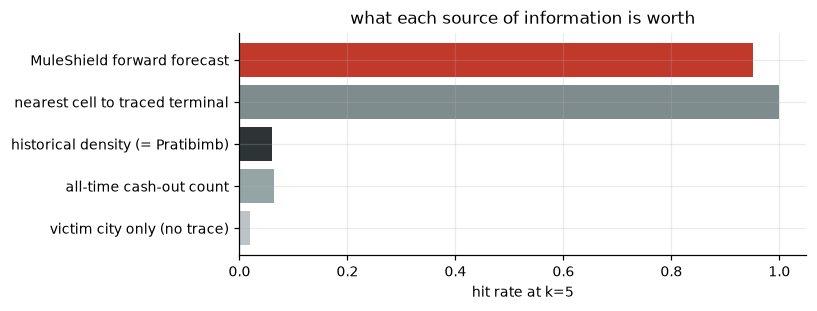

In [6]:
rows = []
for key, label in [("_forecast", "MuleShield forward forecast"),
                   ("baseline_nearest_cell", "nearest cell to traced terminal"),
                   ("baseline_historical_density", "historical density (= Pratibimb)"),
                   ("baseline_static_count", "all-time cash-out count"),
                   ("baseline_victim_city", "victim city only (no trace)")]:
    if key == "_forecast":
        rows.append((label, hs["hit_rate_at_k"][k5], hs["pai_at_k"][k5],
                     hs["rupees_covered_at_k"][k5]))
    else:
        b = hs[key]
        rows.append((label, b["hit_rate_at_5"], b["pai_at_5"], b["rupees_covered_at_5"]))

bl = pd.DataFrame(rows, columns=["at k=5", "hit_rate", "PAI", "rupees_covered"])
display(bl.set_index("at k=5").round(4))

dens = hs["baseline_historical_density"]
print(f"vs historical density : PAI {hs['pai_at_k'][k5]:.2f} against "
      f"{dens['pai_at_5']:.2f}  = {hs['pai_at_k'][k5] / max(dens['pai_at_5'], 1e-9):.1f}x")
print(f"                        hit rate {hs['hit_rate_at_k'][k5]:.4f} against "
      f"{dens['hit_rate_at_5']:.4f}")
print(f"ledger says beats_historical_density = {hs['beats_historical_density']}")
print(f"ledger says beats_nearest_cell       = {hs['beats_nearest_cell']}  "
      f"<- reported, not hidden")

fig, ax = plt.subplots(figsize=(7.5, 2.9))
colors = ["#c0392b", "#7f8c8d", "#2d3436", "#95a5a6", "#bdc3c7"]
ax.barh(bl["at k=5"][::-1], bl["hit_rate"][::-1], color=colors[::-1])
ax.set_xlabel("hit rate at k=5"); ax.set_xlim(0, 1.05)
ax.set_title("what each source of information is worth")
plt.tight_layout(); plt.show()

## 6 Â· "In Advance", measured

The claim in the problem statement's title is a claim about *time*, so it gets a
number: how many minutes of warning exist between the forecast being available
and the withdrawal happening. A forecast that lands after the cash is gone is a
report.

15 minutes is used as the threshold for "actionable" â€” roughly the time to raise
a district control room and move a unit.

median lead time     : 41.5 min
p10 lead time        : 4.9 min   <- the unlucky tail, published
actionable (>=15 min): 84.1% of held-out cash-outs


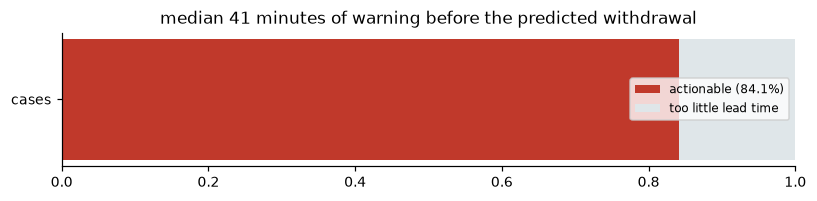


cells searched per genuine interception at k=5: 5.25
That is the false-positive answer, stated before anyone has to ask for it.


In [7]:
lead = hs["lead_time_median_min"]
p10 = hs["lead_time_p10_min"]
act = hs["lead_actionable_rate"]

print(f"median lead time     : {lead:.1f} min")
print(f"p10 lead time        : {p10:.1f} min   <- the unlucky tail, published")
print(f"actionable (>=15 min): {act:.1%} of held-out cash-outs")

fig, ax = plt.subplots(figsize=(7.5, 1.9))
ax.barh(["cases"], [act], color="#c0392b", label=f"actionable ({act:.1%})")
ax.barh(["cases"], [1 - act], left=[act], color="#dfe6e9",
        label="too little lead time")
ax.set_xlim(0, 1); ax.legend(fontsize=8, loc="center right"); ax.grid(False)
ax.set_title(f"median {lead:.0f} minutes of warning before the predicted withdrawal")
plt.tight_layout(); plt.show()

cells_per_hit = int(k5) / max(hs["hit_rate_at_k"][k5], 1e-9)
print(f"\ncells searched per genuine interception at k={k5}: {cells_per_hit:.2f}")
print("That is the false-positive answer, stated before anyone has to ask for it.")

## 7 Â· The leak checks that this evaluation has to pass

A forward forecast is unusually easy to cheat, because the future is sitting in
the same dataframe. Four guards, all mechanical:

1. **Split by complaint, never by row.** One complaint fans out to 25 candidate
   rows; splitting by row puts the same event on both sides.
2. **`HISTORY_FRACTION = 0.5`.** The earliest half of complaints is reserved as
   prior-only and never enters the ranking set, so the historical prior cannot be
   built from an event it is later scored on.
3. **The countdown comes from the regressor, not from the data.** An earlier
   revision fed the *observed* `time_to_cashout_min` into the survival kernel â€”
   the answer, used to predict the answer. It is recorded in
   `REMEDIATION_AUDIT.md` Â§2.1 with both the leaked and the clean numbers.
4. **One code path.** The evaluation scores through the same
   `hotspot.posterior_from_scores` the API serves from, so a metrics/serving skew
   is impossible by construction rather than by discipline.

In [8]:
import inspect
from feature_builder import FeatureBuilder

print("HISTORY_FRACTION :", FeatureBuilder.HISTORY_FRACTION,
      " <- earliest half held back as prior-only")

src = inspect.getsource(H.posterior_from_scores)
print("\nthe one scoring path, shared by the evaluation and the API:\n")
print(src)

print("split reproduced by the evaluation script:")
print(f"  held-out cash-outs   : {hs['n_test_cashouts']}")
print(f"  held-out complaints  : {hs['n_test_complaints']}")
print(f"  open window          : {hs['open_minutes']} min")
print(f"  windows              : {hs['windows_min']}")

HISTORY_FRACTION : 0.5  <- earliest half held back as prior-only

the one scoring path, shared by the evaluation and the API:

def posterior_from_scores(atm_ids: Sequence[str],
                          raw_scores: Sequence[float]) -> dict[str, float]:
    """Softmax the ranker's raw candidate scores into a choice distribution.

    This is the SAME transformation MuleXGBPredictor.predict applies to produce
    the confidence an operator sees -- "the softmax over the candidate set is
    the model's own choice probability, so the confidences shown to an operator
    are calibrated by construction" (xgb_model.py).

    It lives here as a named function so the evaluation script and the serving
    path call one implementation. A metrics/serving skew is then impossible by
    construction rather than by discipline -- which matters, because a hotspot
    figure that was measured with a different softmax than the API serves would
    be exactly the class of defect the leakage audit was writ

## 8 Â· The defect this build found: a live complaint the surface could not see

Worth reproducing here because it is the most instructive failure in the project.

The backend stamps an ingested complaint with `datetime.now(timezone.utc)`. The
seeded corpus carries naive **local** time. `parse_ts` reconciled the two by
calling `.replace(tzinfo=None)` â€” which *discards* the offset rather than
applying it. On an IST machine a complaint filed one second ago measured as 330
minutes old, fell outside the 120-minute open window, and was dropped from the
forecast at the moment it arrived.

397 tests passed throughout, because every one of them replays a historical epoch
with an `as_of` drawn from the same naive-local corpus â€” the offset cancels on
both sides. Only a real UTC-stamped complaint meeting a real wall clock exposes
it, and no automated test walked that path.

In [9]:
from datetime import datetime, timezone

utc_stamp = datetime.now(timezone.utc).isoformat()
parsed = H.parse_ts(utc_stamp)
age_min = (datetime.now() - parsed).total_seconds() / 60.0

print("server stamps        :", utc_stamp)
print("parse_ts returns     :", parsed)
print("local wall clock     :", datetime.now())
print(f"age as the surface sees it : {age_min:.2f} min")
print()
if abs(age_min) < 5:
    print("  OK - a complaint filed now is inside the 120-minute open window.")
else:
    print(f"  BROKEN - reads {age_min:.0f} min old; the open window is "
          f"{hs['open_minutes']} min, so it would never reach the surface.")

broken = datetime.fromisoformat(utc_stamp).replace(tzinfo=None)
print(f"\nthe old behaviour, for comparison: "
      f"{(datetime.now() - broken).total_seconds() / 60:.0f} min old")

server stamps        : 2026-09-01T15:12:29.938490+00:00
parse_ts returns     : 2026-09-01 20:42:29.938490
local wall clock     : 2026-09-01 20:42:29.938778
age as the surface sees it : 0.00 min

  OK - a complaint filed now is inside the 120-minute open window.

the old behaviour, for comparison: 330 min old


## 9 Â· From surface to dispatch

The forecast is only worth the action it triggers, so four rules read this same
surface (`backend/notify.py`) and raise CRITICAL / HIGH / WATCH alerts:

| Rule | Fires when |
|---|---|
| `R-CRIT-RUPEES` | â‰¥ â‚¹50 lakh forecast inside 60 minutes |
| `R-HIGH-CONVERGE` | â‰¥ 3 open cases converge on one cell **and** conditional share â‰¥ 0.60 |
| `R-HIGH-REGISTRY` | a cell contains an account already flagged by MuleHunter.AI / Samanvaya |
| `R-WATCH-SCORE` | cell scores in the top decile of cells **with live evidence** |

Two of those carry an explicit **conditional-share floor**, which is the
anti-Pratibimb constraint living in the dispatch policy rather than only in the
display: a cell cannot raise a HIGH alert on historical pattern alone. That floor
was added after the first live pass raised 66 alerts of which 48 had **zero open
cases** â€” pure prior, wearing an alert's clothing. `REMEDIATION_AUDIT.md` Â§2.3
has the story; 66 became 3.

Nothing is dispatched and no account is frozen without an officer acknowledging
an alert with a disposition, and *False positive* is one of the four buttons.

In [10]:
print("published summary")
print("=" * 62)
for label, value in [
    ("cells / radius", f"{hs['n_cells']} at {hs['cell_radius_km']:.0f} km"),
    ("held-out cash-outs", hs["n_test_cashouts"]),
    (f"hit rate @k={k5}", f"{hs['hit_rate_at_k'][k5]:.4f}"),
    (f"PAI @k={k5}", f"{hs['pai_at_k'][k5]:.2f}"),
    ("PAI, historical density", f"{hs['baseline_historical_density']['pai_at_5']:.2f}"),
    (f"rupees covered @k={k5}", f"{hs['rupees_covered_at_k'][k5]:.4f}"),
    ("median lead time", f"{hs['lead_time_median_min']:.1f} min"),
    ("actionable rate", f"{hs['lead_actionable_rate']:.1%}"),
    ("prior share / cap", f"{hs['prior_share_national']} / {hs['prior_weight']}"),
    ("beats historical density", hs["beats_historical_density"]),
    ("beats nearest-cell", hs["beats_nearest_cell"]),
]:
    print(f"  {label:26s} {value}")
print("=" * 62)
print("source :", hs["source"])
print("measured:", hs["measured_utc"])

published summary
  cells / radius             222 at 12 km
  held-out cash-outs         621
  hit rate @k=5              0.9517
  PAI @k=5                   26.86
  PAI, historical density    1.09
  rupees covered @k=5        0.9561
  median lead time           41.5 min
  actionable rate            84.1%
  prior share / cap          0.1304 / 0.15
  beats historical density   True
  beats nearest-cell         False
source : python scripts/evaluate_hotspots.py
measured: 2026-09-01T14:50:49Z
